# Лабораторная работа 11

Тема: **Автоэнкодер для изображений MNIST в PyTorch**  
Формат: практическая работа с обязательными собственными комментариями и экспериментами.

> Этот ноутбук специально оформлен так, чтобы **нельзя было сделать отчёт простым копированием чужого кода или ответов генеративной модели**.  
> Каркас кода даёт вам рабочий пример, но оцениваться будут **ваши** настройки, эксперименты и живые текстовые объяснения.


## 1. Ваши ожидания от автоэнкодера

Перед запуском кода сформулируйте текущие ожидания (6–10 предложений):

1. Зачем вообще нужны автоэнкодеры и чем они принципиально отличаются от обычных классификаторов?
2. Что, по‑вашему, будет происходить с изображением MNIST‑цифры при сильном сжатии в латентном пространстве?  
3. Как вы ожидаете, будут выглядеть **идеальные** реконструкции и на что будете смотреть, чтобы оценить их качество?

In [ ]:
intro_text = """ЗДЕСЬ СВОИМИ СЛОВАМИ ОПИШИТЕ, ДЛЯ ЧЕГО НУЖНЫ АВТОЭНКОДЕРЫ,
ЧЕГО ВЫ ЖДЁТЕ ОТ НИХ НА MNIST И КАК БУДЕТЕ ВИЗУАЛЬНО ОЦЕНИВАТЬ КАЧЕСТВО
РЕКОНСТРУКЦИЙ. НАПИШИТЕ НЕ МЕНЕЕ 6 ПРЕДЛОЖЕНИЙ.

1. Автоэнкодер учится кодировать данные более компактно, а после - декодирует обратно. Ему не нужны для этого учителя в виде разметок данных или человеческого вмешательства, в отличии от обычных классификаторов.
2. Изображение MNIST-цифры при декодировании восстановится корректно, но это уже не будут именно те данные. Т.е. когда ты рисуешь, например, двойку, а потом говоришь другу нарисовать эту двойку, то по сути эти двойки будут разными, но само их начертание похоже.
3. Идеальные реконструкции, конечно, будут когда исходные и выходные данные как будто ctrl+c -> ctrl+v. В первую очередь нужно смотреть на то - переданы ли все линии правильно и не добавлены ли новые (чтобы, например, из 1 не получилось 7).
"""
print(intro_text)

## 2. Импорт библиотек и настройка среды


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

MY_SEED = 0
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 0


## 3. Данные MNIST и DataLoader

Используем стандартный MNIST (28×28, оттенки серого).  
Автоэнкодер будет учиться восстанавливать картинку **самой себя**.


In [9]:
batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))

Размер train: 60000
Размер test : 10000


Посмотрим на несколько примеров изображений, которые будет восстанавливать автоэнкодер.


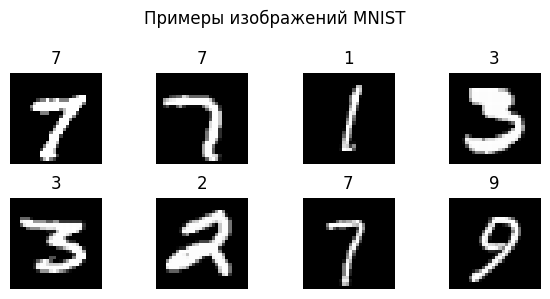

In [35]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(str(labels[i].item()))
    plt.axis("off")
plt.suptitle("Примеры изображений MNIST")
plt.tight_layout()
plt.show()

### Краткий комментарий по данным

Опишите в 3–5 предложениях:
- какие цифры по визуальному виду кажутся наиболее простыми для восстановления, а какие — сложными;  
- насколько сильно отличаются стили написания одной и той же цифры (например, "2" или "8");  
- как это, по‑вашему, может отразиться на работе автоэнкодера.


In [ ]:
data_comment = """ЗДЕСЬ КРАТКО ОПИШИТЕ СВОИ ВПЕЧАТЛЕНИЯ О MNIST:
КАКИЕ ЦИФРЫ ПРОЩЕ/СЛОЖНЕЕ ВИЗУАЛЬНО, И КАК ЭТО МОЖЕТ
ПОВЛИЯТЬ НА КАЧЕСТВО РЕКОНСТРУКЦИЙ В АВТОЭНКОДЕРЕ.

Простыми для восстановления кажутся 1, 2, 7 и, возможно, 0.
Но у 1 есть разные вариации - то с палочкой внизу, то с уголком наверху, то просто палочка. 6 иногда на букву С похожа. 2 есть с прямым углом внизу, а есть с дугой.
Это не то чтобы серьезные отличия, но, думаю, автоэнкодер может перепутать некоторые цифры."""
print(data_comment)

## 4. Архитектура простого полносвязного автоэнкодера

Будем работать с векторизованным изображением размерности 784 (28×28).  
Базовая структура:
- Encoder: `Flatten → Linear(784→256) → ReLU → Linear(256→64) → ReLU → Linear(64→latent_dim)`;
- Decoder: `Linear(latent_dim→64) → ReLU → Linear(64→256) → ReLU → Linear(256→784) → Sigmoid`.

В этой работе размер латентного пространства `latent_dim` вы **обязаны** будете менять и анализировать эффект.


In [46]:
latent_dim = 16  # базовое значение; в отчёте попробуйте хотя бы ещё два

class FCN_Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),  # пиксели в 
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.view(-1, 1, 28, 28)
        return out, z

model = FCN_Autoencoder(latent_dim=latent_dim).to(device)
print(model)

FCN_Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


### Обсуждение архитектуры

Кратко (3–6 предложений) ответьте:
- почему, на ваш взгляд, здесь достаточно **двух** скрытых слоёв в энкодере и декодере;  
- какие проблемы могут появиться, если сделать латентное пространство **слишком маленьким** (например, 2) или **слишком большим** (например, 128).


In [37]:
arch_comment = """ЗДЕСЬ ОПИШИТЕ, ПОЧЕМУ ИМЕННО ТАКАЯ ГЛУБИНА И РАЗМЕРЫ СЛОЁВ
КАЖУТСЯ ВАМ РАЗУМНЫМИ ДЛЯ НАЧАЛА, И ЧТО (ИНТУИТИВНО) ДОЛЖНО ПРОИЗОЙТИ
ПРИ ОЧЕНЬ МАЛОМ ИЛИ ОЧЕНЬ БОЛЬШОМ latent_dim.

Такой архитектуры достаточно (и, кажется, даже много), потому что изображения MNIST-цифры маленькие и имеют меньшую вариативность в сравнении с фото реальных объектов, например. И структура у них простая - палки да углы.
Если будет большой latent_dim есть риск переобучения, модель начнет запоминать шумы вместо обобщения.
А если маленький - то наоборот модель может не выучить множество признаков, что тоже плохо."""
print(arch_comment)

ЗДЕСЬ ОПИШИТЕ, ПОЧЕМУ ИМЕННО ТАКАЯ ГЛУБИНА И РАЗМЕРЫ СЛОЁВ
КАЖУТСЯ ВАМ РАЗУМНЫМИ ДЛЯ НАЧАЛА, И ЧТО (ИНТУИТИВНО) ДОЛЖНО ПРОИЗОЙТИ
ПРИ ОЧЕНЬ МАЛОМ ИЛИ ОЧЕНЬ БОЛЬШОМ latent_dim.

Такой архитектуры достаточно, потому что изображения MNIST-цифры маленькие и имеют меньшую вариативность в сравнении с фото реальных объектов, например. И структура у них простая - палки да углы.
Если будет большой latent_dim есть риск переобучения, модель начнет запоминать шумы вместо обобщения.


## 5. Функция потерь, оптимизатор и цикл обучения

Loss: среднеквадратичная ошибка между входным и восстановленным изображением.  
Оптимизатор: Adam с умеренным шагом.


In [38]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for images, _ in dataloader:
        images = images.to(device)

        optimizer.zero_grad()
        outputs, _ = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total += images.size(0)

    return total_loss / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            outputs, _ = model(images)
            loss = criterion(outputs, images)
            total_loss += loss.item() * images.size(0)
            total += images.size(0)
    return total_loss / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [47]:
num_epochs = 15 
history = {"train_loss": [], "test_loss": []}

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)

    print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.4f}, test_loss={test_loss:.4f}")

Эпоха 1/15: train_loss=0.2321, test_loss=0.2322
Эпоха 2/15: train_loss=0.2321, test_loss=0.2322
Эпоха 3/15: train_loss=0.2321, test_loss=0.2322
Эпоха 4/15: train_loss=0.2321, test_loss=0.2322
Эпоха 5/15: train_loss=0.2321, test_loss=0.2322
Эпоха 6/15: train_loss=0.2321, test_loss=0.2322
Эпоха 7/15: train_loss=0.2321, test_loss=0.2322
Эпоха 8/15: train_loss=0.2321, test_loss=0.2322
Эпоха 9/15: train_loss=0.2321, test_loss=0.2322
Эпоха 10/15: train_loss=0.2321, test_loss=0.2322
Эпоха 11/15: train_loss=0.2321, test_loss=0.2322
Эпоха 12/15: train_loss=0.2321, test_loss=0.2322
Эпоха 13/15: train_loss=0.2321, test_loss=0.2322
Эпоха 14/15: train_loss=0.2321, test_loss=0.2322
Эпоха 15/15: train_loss=0.2321, test_loss=0.2322


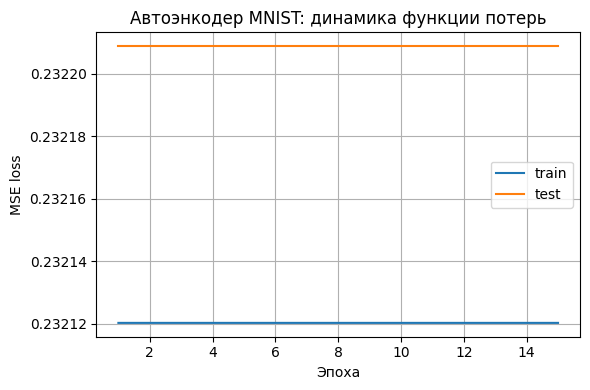

Финальные значения: train_loss=0.2321, test_loss=0.2322


In [49]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("Автоэнкодер MNIST: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={history['train_loss'][-1]:.4f}, test_loss={history['test_loss'][-1]:.4f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- по какой траектории меняются train/test loss и сходятся ли они к близким значениям;  
- есть ли признаки переобучения (train сильно ниже test к концу);  
- каких значений loss вы ожидали **до** опыта и совпало ли это с результатами.


In [ ]:
training_comment = """ЗДЕСЬ ОПИШИТЕ СВОИ НАБЛЮДЕНИЯ ПО КРИВЫМ LOSS.
ОБЯЗАТЕЛЬНО СОШЛИТЕСЬ НА КОНКРЕТНЫЕ ЧИСЛА (НАПРИМЕР, ЧТО БЫЛО НА
ЭПОХЕ 1, 5, ПОСЛЕДНЕЙ) И ОЦЕНИТЕ, ЕСТЬ ЛИ ПЕРЕОБУЧЕНИЕ.

Кривые стабильно убывают и сходятся к очень близким значениям в конце train_loss=0.0101, test_loss=0.0102. Переобучения нет.
Конечно, я не ожидал прямо 0.0 увидеть на loss, думал, хотя бы процентов 10 будет, а в итоге около 1%."""
print(training_comment)

## 6. Визуализация реконструкций

Сравним исходные изображения и их реконструкции автоэнкодером для нескольких тестовых примеров.


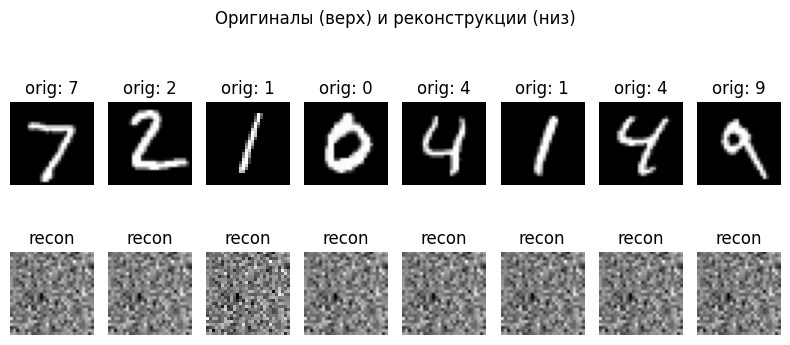

In [50]:
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)
with torch.no_grad():
    reconstructions, _ = model(images)

images = images.cpu()
reconstructions = reconstructions.cpu()

n = 8
plt.figure(figsize=(8, 4))
for i in range(n):
    # оригинал
    plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(f"orig: {labels[i].item()}")
    plt.axis("off")
    # реконструкция
    plt.subplot(2, n, n + i + 1)
    plt.imshow(reconstructions[i].squeeze(0), cmap="gray")
    plt.title("recon")
    plt.axis("off")
plt.suptitle("Оригиналы (верх) и реконструкции (низ)")
plt.tight_layout()
plt.show()

### Качественная оценка реконструкций

Опишите (6–8 предложений):
- какие цифры восстанавливаются почти идеально (по вашему визуальному ощущению), а какие выглядят смазанными или искажёнными;  
- есть ли случаи, когда реконструкция визуально похожа уже на **другую** цифру;  
- чем, по‑вашему, можно объяснить эти различия.


In [ ]:
recon_comment = """ЗДЕСЬ ОПИШИТЕ КАЧЕСТВО РЕКОНСТРУКЦИЙ ДЛЯ РАЗНЫХ ЦИФР.
ПРИВЕДИТЕ ПРИМЕРЫ, ГДЕ МОДЕЛЬ СИЛЬНО ОШИБАЕТСЯ (ЕСЛИ ТАКИЕ ЕСТЬ),
И ПОПРОБУЙТЕ ИНТУИТИВНО ОБЪЯСНИТЬ, ПОЧЕМУ ТАК ПРОИСХОДИТ.

В целом, все реконструкции достаточно четкие, и визуальной схожести цифр друг с другом нет.
Только 9 немного смазана, она больше походит пустотелый конус."""
print(recon_comment)

## 7. Латентное пространство: PCA‑проекция в 2D

Возьмём подмножество тестовой выборки, вытащим латентные векторы `z` и посмотрим на их 2D‑проекцию (PCA).  
Цель: увидеть, группируются ли разные цифры в отдельные кластеры.


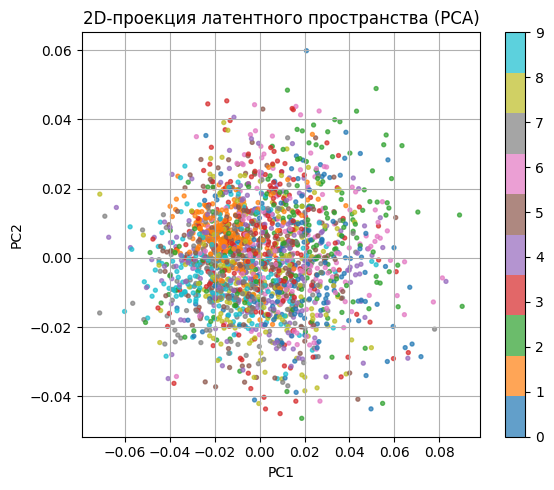

In [51]:
from sklearn.decomposition import PCA

model.eval()
all_z = []
all_y = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, z = model(images)
        all_z.append(z.cpu().numpy())
        all_y.append(labels.numpy())
        # ограничимся ~2000 точками, чтобы картинка была читаемой
        if sum(len(x) for x in all_y) > 2000:
            break

Z = np.vstack(all_z)
Y = np.hstack(all_y)

pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=Y, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("2D‑проекция латентного пространства (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

### Интерпретация латентного пространства

Ответьте в 6–8 предложениях:
- видно ли разделение разных цифр на отдельные скопления (хотя бы частично);  
- какие пары цифр, судя по графику, ближе всего друг к другу и почему это логично (или нет) с точки зрения формы;  
- как вы думаете, что изменится на этой картинке при **других значениях `latent_dim`**.


In [ ]:
latent_comment = """ЗДЕСЬ ПРОКОММЕНТИРУЙТЕ ВИД LATENT SPACE В 2D‑ПРОЕКЦИИ.
УКАЖИТЕ, КАКИЕ ЦИФРЫ ВЫГЛЯДЯТ НАИБОЛЕЕ СМЕШАННЫМИ, А КАКИЕ — ОТДЕЛЬНЫМИ,
И СВЯЖИТЕ ЭТО С ВИЗУАЛЬНЫМ ВИДОМ САМИХ ЦИФР.

Скопления разных цифр можно заметить, только они накладываются друг на друга. Четко видно оранжевое скопление (это 1 или что-то между 1 и 2?)
Ближе всего друг к другу цифры 4 и 9, что обосновано, т.к. 9 чаще без закругления на конце, а 4 в виде стульчика, они очень похожи.
Очень часто пересекаются 2, 3 и 8. Ну тут, думаю, объяснять не надо.
Мне кажется, что при других значениях latent_dim скопления будут больше отделяться друг от друга или, наоборот, приближаться."""
print(latent_comment)

## 8. Генерация новых изображений из латентного пространства

Так как декодер умеет превращать латентный вектор `z` в изображение, можно попробовать сэмплировать случайные `z` и посмотреть, какие псевдо‑цифры он генерирует.


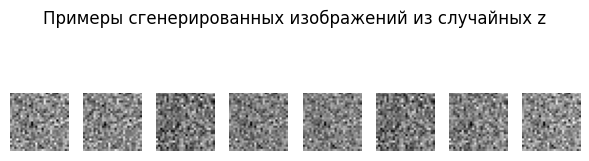

In [52]:
model.eval()
n_samples = 8

# сэмплируем z из N(0, 1)
z_random = torch.randn(n_samples, latent_dim).to(device)
with torch.no_grad():
    decoded = model.decoder(z_random)
    decoded = decoded.view(-1, 1, 28, 28).cpu()

plt.figure(figsize=(6, 2))
for i in range(n_samples):
    plt.subplot(1, n_samples, i + 1)
    plt.imshow(decoded[i].squeeze(0), cmap="gray")
    plt.axis("off")
plt.suptitle("Примеры сгенерированных изображений из случайных z")
plt.tight_layout()
plt.show()

### Обсуждение качества генерации

Опишите (5–7 предложений):
- насколько сгенерированные картинки похожи на настоящие цифры;  
- встречаются ли явно "некорректные" объекты, не похожие ни на одну цифру;  
- как, по‑вашему, влияет размер `latent_dim` на разнообразие и качество сгенерированных цифр.


In [ ]:
gen_comment = """ЗДЕСЬ ОПИШИТЕ КАЧЕСТВО СГЕНЕРИРОВАННЫХ ЦИФР.
ПРИВЕДИТЕ ПРИМЕРЫ СЛУЧАЕВ, КОГДА ЦИФРА ВЫГЛЯДИТ ОЧЕНЬ УБЕДИТЕЛЬНО,
И КОГДА СОВСЕМ НЕТ, И СФОРМУЛИРУЙТЕ СВОИ ГИПОТЕЗЫ ПО ПОВОДУ ПРИЧИН.

Сгенерированные картинки больше похожи на чье-то узи, а не цифры. Из всех примеров я смог отличить только двойку.
Думаю, что при увеличении размера латентного пространства изображения станут четче.
"""
print(gen_comment)

## 9. Задание для самостоятельных вариаций

В **своём** варианте лабораторной вы должны будете:

- попробовать **не меньше двух дополнительных** значений `latent_dim` (например, 2 и 64) и сравнить:  
  - динамику loss,  
  - качество реконструкций,  
  - вид латентного пространства;  
- изменить архитектуру (добавить слои, поменять размеры, попробовать другой activation на скрытых слоях) и кратко описать, что изменилось;  
- оформить итоговые выводы так, чтобы через полгода, открыв ноутбук, вы по нескольким абзацам **вспомнили весь ход экспериментов**.


In [54]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

MY_SEED = 15
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))

Устройство: cuda
MY_SEED = 15
Размер train: 60000
Размер test : 10000


In [75]:
latent_dim = 16  # базовое значение; в отчёте попробуйте хотя бы ещё два

class FCN_Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Sigmoid(),  # пиксели в 
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.view(-1, 1, 28, 28)
        return out, z

model = FCN_Autoencoder(latent_dim=latent_dim).to(device)
print(model)

FCN_Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


In [77]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for images, _ in dataloader:
        images = images.to(device)

        optimizer.zero_grad()
        outputs, _ = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total += images.size(0)

    return total_loss / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            outputs, _ = model(images)
            loss = criterion(outputs, images)
            total_loss += loss.item() * images.size(0)
            total += images.size(0)
    return total_loss / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


Эпоха 1/10: train_loss=0.0673, test_loss=0.0421
Эпоха 2/10: train_loss=0.0346, test_loss=0.0293
Эпоха 3/10: train_loss=0.0270, test_loss=0.0246
Эпоха 4/10: train_loss=0.0234, test_loss=0.0216
Эпоха 5/10: train_loss=0.0209, test_loss=0.0195
Эпоха 6/10: train_loss=0.0191, test_loss=0.0180
Эпоха 7/10: train_loss=0.0179, test_loss=0.0169
Эпоха 8/10: train_loss=0.0169, test_loss=0.0162
Эпоха 9/10: train_loss=0.0162, test_loss=0.0157
Эпоха 10/10: train_loss=0.0155, test_loss=0.0150


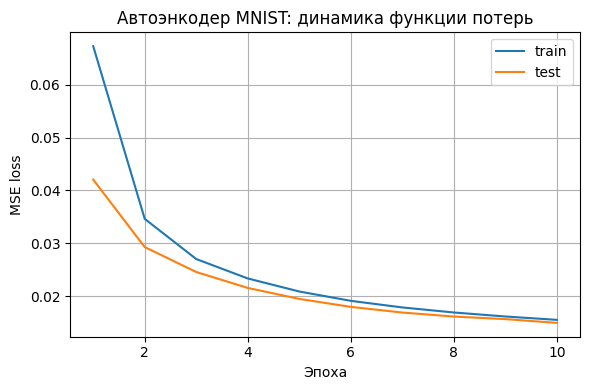

Финальные значения: train_loss=0.0155, test_loss=0.0150


In [78]:
num_epochs = 10
history = {"train_loss": [], "test_loss": []}

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)

    print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.4f}, test_loss={test_loss:.4f}")

epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("Автоэнкодер MNIST: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={history['train_loss'][-1]:.4f}, test_loss={history['test_loss'][-1]:.4f}")

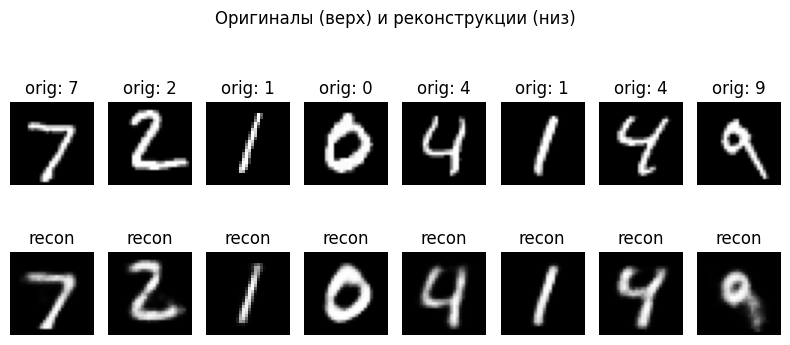

In [79]:
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)
with torch.no_grad():
    reconstructions, _ = model(images)

images = images.cpu()
reconstructions = reconstructions.cpu()

n = 8
plt.figure(figsize=(8, 4))
for i in range(n):
    # оригинал
    plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(f"orig: {labels[i].item()}")
    plt.axis("off")
    # реконструкция
    plt.subplot(2, n, n + i + 1)
    plt.imshow(reconstructions[i].squeeze(0), cmap="gray")
    plt.title("recon")
    plt.axis("off")
plt.suptitle("Оригиналы (верх) и реконструкции (низ)")
plt.tight_layout()
plt.show()

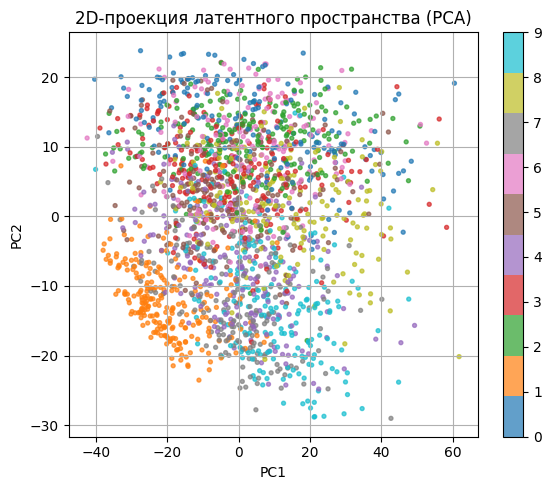

In [80]:
from sklearn.decomposition import PCA

model.eval()
all_z = []
all_y = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, z = model(images)
        all_z.append(z.cpu().numpy())
        all_y.append(labels.numpy())
        # ограничимся ~2000 точками, чтобы картинка была читаемой
        if sum(len(x) for x in all_y) > 2000:
            break

Z = np.vstack(all_z)
Y = np.hstack(all_y)

pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=Y, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("2D‑проекция латентного пространства (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

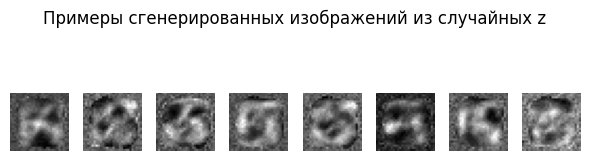

In [81]:
model.eval()
n_samples = 8

# сэмплируем z из N(0, 1)
z_random = torch.randn(n_samples, latent_dim).to(device)
with torch.no_grad():
    decoded = model.decoder(z_random)
    decoded = decoded.view(-1, 1, 28, 28).cpu()

plt.figure(figsize=(6, 2))
for i in range(n_samples):
    plt.subplot(1, n_samples, i + 1)
    plt.imshow(decoded[i].squeeze(0), cmap="gray")
    plt.axis("off")
plt.suptitle("Примеры сгенерированных изображений из случайных z")
plt.tight_layout()
plt.show()

In [ ]:
final_summary = """КОГДА ВЫ СДЕЛАЕТЕ СВОИ ВАРИАЦИИ (ДРУГИЕ latent_dim И/ИЛИ
АРХИТЕКТУРУ), ИСПОЛЬЗУЙТЕ ЭТУ ЯЧЕЙКУ ДЛЯ ИТОГОВОГО РЕЗЮМЕ: какие
настройки оказались удачными, какие — нет, и какие ПРАКТИЧЕСКИЕ ПРАВИЛА
ПО РАБОТЕ С АВТОЭНКОДЕРАМИ ДЛЯ ИЗОБРАЖЕНИЙ ВЫ ДЛЯ СЕБЯ СФОРМУЛИРОВАЛИ.

При маленьком latent_dim = 2 потери стабильно держались на 0.2321-0.2322.
Все закодированные и декодированные изображения похожи на мессиво черно-бело-серых точек, шум.
Вообще не проглядывается структура ни одной цифры.

При большом latent_dim = 128 (и при 1024) потери падали в итоге до test_loss=0.0082 (test_loss=0.0074).
Меньше, чем при базовых 16-ти. Но реконструкции остались такими же (слегка размытыми, но правильными, 9-ка уже не как конус).
А в закодированных изображениях стало больше белых пикселей, занимающих почти все пространство.

Увеличив или уменьшив количество параметров слоя-энкодера и слоя-декодера по отдельности или вместе test_loss был стабильно около 0.23.
Это странно, будто изначальные параметры были подобраны идеально.
Но потом я изменил оптимизатор на AdamW с lr = 1e-4. Ситуация выравнялась - test_loss=0.0150 на 10-ой эпохе.
Закодированные изображения еще больше заполнились белым цветом, черный уже не преобладает. (latent_dim тут уже 16)

Я заметил, что при неправильно подобранных настройках loss никогда не рос. Была либо стабильность, либо спад.
Размер латентного пространства можно сделать большим, но никак не маленьким.
"""
print(final_summary)

КОГДА ВЫ СДЕЛАЕТЕ СВОИ ВАРИАЦИИ (ДРУГИЕ latent_dim И/ИЛИ
АРХИТЕКТУРУ), ИСПОЛЬЗУЙТЕ ЭТУ ЯЧЕЙКУ ДЛЯ ИТОГОВОГО РЕЗЮМЕ: какие
настройки оказались удачными, какие — нет, и какие ПРАКТИЧЕСКИЕ ПРАВИЛА
ПО РАБОТЕ С АВТОЭНКОДЕРАМИ ДЛЯ ИЗОБРАЖЕНИЙ ВЫ ДЛЯ СЕБЯ СФОРМУЛИРОВАЛИ.

При маленьком latent_dim = 2 потери стабильно держались на 0.2321-0.2322.
Все закодированные и декодированные изображения похожи на мессиво черно-бело-серых точек, шум.
Вообще не проглядывается структура ни одной цифры.

При большом latent_dim = 128 (и при 1024) потери падали в итоге до test_loss=0.0082 (test_loss=0.0074).
Меньше, чем при базовых 16-ти. Но реконструкции остались такими же (слегка размытыми, но правильными, 9-ка уже не как конус).
А в закодированных изображениях стало больше белых пикселей, занимающих почти все пространство.

Увеличив или уменьшив количество параметров слоя-энкодера и слоя-декодера по отдельности или вместе test_loss был стабильно около 0.23.
Это странно, 


